In [10]:
import pyfar as pf
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [21]:
# Import audio signals
# m1_1 = pf.io.read_audio('Audio/1.Brandenburg_M1.wav')
# m2_1 = pf.io.read_audio('Audio/1.Brandenburg_M2.wav')
m1_1 = pf.io.read_audio('Audio/2.Friedrich_M1.wav')
m2_1 = pf.io.read_audio('Audio/2.Friedrich_M2.wav')
fs_1 = m1_1.sampling_rate

m1_6 = pf.io.read_audio('Audio/6.Mozart_M1.wav')
m3_6 = pf.io.read_audio('Audio/6.Mozart_M3.wav')
fs_6 = m1_6.sampling_rate

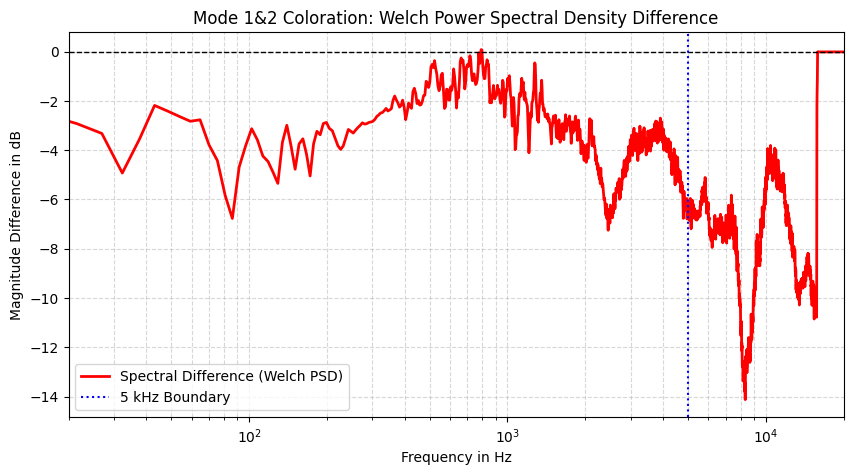

The maximum loudest coloration peak reaches: 14.12 dB


In [22]:
# Long-term average spectral difference based on Welch's method
# Evaluation indicators: Timbral Fidelity / Coloration (optimized for long music signals)
 
# 1. Calculate power spectral density (PSD) using Welch’s method
# nperseg=8192 provides approximately 5Hz frequency resolution.
# It cuts long music into countless small pieces and averages them. 
freqs_1, psd_m1 = signal.welch(m1_1.time, fs_1, nperseg=8192, axis=-1)
freqs_1, psd_m2 = signal.welch(m2_1.time, fs_1, nperseg=8192, axis=-1)

# 2. Average the energy of the left and right ears (channels 0 and 1) to represent the overall timbre perception.
psd_m1_mono = np.mean(psd_m1, axis=0)
psd_m2_mono = np.mean(psd_m2, axis=0)

# 3. Convert to dB 
# Note: Because it is already a power spectrum (Power), the formula is 10 *log10.
ref_dB = 10 * np.log10(psd_m1_mono + 1e-12)
test_dB = 10 * np.log10(psd_m2_mono + 1e-12)
# Calculation of acoustic coloration (test signal -reference signal)
coloration_dB = test_dB - ref_dB

# 4. Visualization
plt.figure(figsize=(10, 5))
plt.semilogx(freqs_1, coloration_dB, color='red', linewidth=2, label='Spectral Difference (Welch PSD)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Mark the 5kHz boundary
plt.axvline(x=5000, color='blue', linestyle=':', label='5 kHz Boundary')

plt.title('Mode 1&2 Coloration: Welch Power Spectral Density Difference')
plt.xlabel('Frequency in Hz')
plt.ylabel('Magnitude Difference in dB')
plt.xlim([20, 20000])
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# Conclusion output
# Obtain maximum coloration peaks within the core auditory frequency band
valid_idx = (freqs_1 > 100) & (freqs_1 < 10000)
max_coloration = np.max(np.abs(coloration_dB[valid_idx]))
print(f"The maximum loudest coloration peak reaches: {max_coloration:.2f} dB")

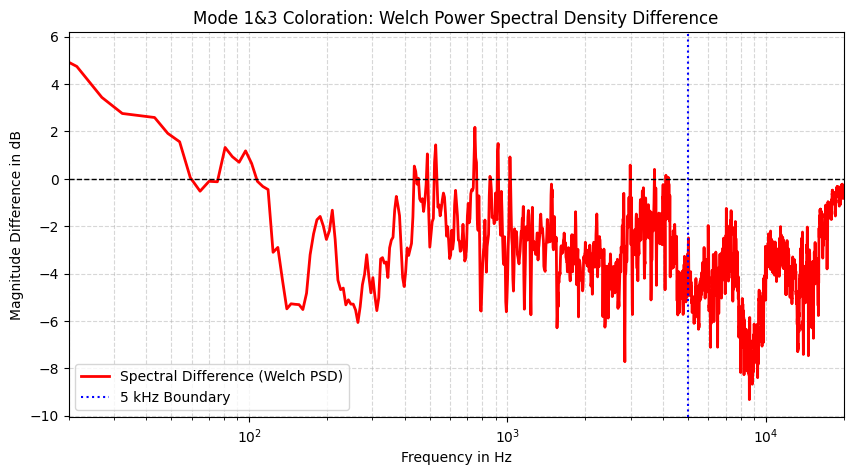

The maximum loudest coloration peak reaches (mode 1&3): 9.32 dB


In [19]:
# --- Same analysis for m1_6 vs m3_6 ---
freqs_6, psd_m1_6 = signal.welch(m1_6.time, fs_6, nperseg=8192, axis=-1)
freqs_6, psd_m3_6 = signal.welch(m3_6.time, fs_6, nperseg=8192, axis=-1)

psd_m1_6_mono = np.mean(psd_m1_6, axis=0)
psd_m3_6_mono = np.mean(psd_m3_6, axis=0)

ref_6_dB = 10 * np.log10(psd_m1_6_mono + 1e-12)
test_6_dB = 10 * np.log10(psd_m3_6_mono + 1e-12)
coloration_6_dB = test_6_dB - ref_6_dB

plt.figure(figsize=(10, 5))
plt.semilogx(freqs_6, coloration_6_dB, color='red', linewidth=2, label='Spectral Difference (Welch PSD)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=5000, color='blue', linestyle=':', label='5 kHz Boundary')
plt.title('Mode 1&3 Coloration: Welch Power Spectral Density Difference')
plt.xlabel('Frequency in Hz')
plt.ylabel('Magnitude Difference in dB')
plt.xlim([20, 20000])
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

valid_idx_6 = (freqs_6 > 100) & (freqs_6 < 10000)
max_coloration_6 = np.max(np.abs(coloration_6_dB[valid_idx_6]))
print(f"The maximum loudest coloration peak reaches (mode 1&3): {max_coloration_6:.2f} dB")

In [14]:
# Spatial Orientation Cue (ITD & ILD) Analysis
# Evaluation metric: Spatial Fidelity

def compute_spatial_cues(sig):
    # Calculate ITD (milliseconds) and ILD (decibel) of binaural signals
    fs = sig.sampling_rate
    # sig.time has shape (channels, samples)
    left_ear = sig.time[0]
    right_ear = sig.time[1]
    
    # 1. Calculate ILD (Interaural Level Difference)
    rms_left = np.sqrt(np.mean(left_ear**2))
    rms_right = np.sqrt(np.mean(right_ear**2))
    # The ratio of the right ear to the left ear. A positive number means the sound is to the right, a negative number means it is to the left.
    ild = 20 * np.log10((rms_right + 1e-12) / (rms_left + 1e-12))
    
    # 2. Calculate ITD (Interaural Time Difference)
    # Use cross-correlation to find the time difference between the left and right ears
    cc = signal.correlate(right_ear, left_ear, mode='full')
    lags = signal.correlation_lags(len(right_ear), len(left_ear))
    max_idx = np.argmax(cc)
    
    # Convert to milliseconds
    itd_samples = lags[max_idx]
    itd_ms = (itd_samples / fs) * 1000 
    
    return itd_ms, ild

In [ ]:
# Calculate the reference signal (should be close to 0 since it is directly ahead)
itd_ref, ild_ref = compute_spatial_cues(m1_1)
# Calculate the test signal (should show obvious declination characteristics)
itd_test, ild_test = compute_spatial_cues(m2_1)

print("-" *40)
print(f"Mode 1 signal")
print(f"ITD (time difference): {itd_ref:.3f} ms")
print(f"ILD (sound level difference): {ild_ref:.2f} dB")
print("-" *40)
print(f"Mode 2 signal")
print(f"ITD (time difference): {itd_test:.3f} ms")
print(f"ILD (sound level difference): {ild_test:.2f} dB")
print("-" *40)

----------------------------------------
Mode 1 signal
ITD (time difference): 0.068 ms
ILD (sound level difference): 1.03 dB
----------------------------------------
Mode 2 signal
ITD (time difference): 0.794 ms
ILD (sound level difference): -0.40 dB
----------------------------------------


In [ ]:
# --- Same analysis for m1_6 vs m3_6 ---
itd_ref_6, ild_ref_6 = compute_spatial_cues(m1_6)
itd_test_6, ild_test_6 = compute_spatial_cues(m3_6)

print("-" *40)
print(f"Mode 1 signal (Mozart)")
print(f"ITD (time difference): {itd_ref_6:.3f} ms")
print(f"ILD (sound level difference): {ild_ref_6:.2f} dB")
print("-" *40)
print(f"Mode 3 signal (Mozart)")
print(f"ITD (time difference): {itd_test_6:.3f} ms")
print(f"ILD (sound level difference): {ild_test_6:.2f} dB")
print("-" *40)

----------------------------------------
Mode 1 signal (Mozart)
ITD (time difference): -0.181 ms
ILD (sound level difference): 0.82 dB
----------------------------------------
Mode 3 signal (Mozart)
ITD (time difference): 0.703 ms
ILD (sound level difference): -0.03 dB
----------------------------------------
